# Visualizacion inicial de INbreast
Este notebook usa la funcion de `src` para listar y visualizar mamografias DICOM del dataset INbreast.

In [30]:
import sys
import random
import pydicom
from pathlib import Path


project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from src.visualization import DEFAULT_INBREAST_IMAGES_DIR, list_dicom_images, show_dicom_image

In [2]:
print(DEFAULT_INBREAST_IMAGES_DIR)

/home/eloygarcia/Escritorio/Datasets/inbreast/ALL-IMGS


In [10]:
dicom_paths = list_dicom_images(DEFAULT_INBREAST_IMAGES_DIR)

idx = random.randint(0, len(dicom_paths)-1)

print(f'Total de imagenes DICOM: {len(dicom_paths)}')
print(f'Primera imagen: {dicom_paths[idx].name}')
print(f'Index: {idx}')

Total de imagenes DICOM: 410
Primera imagen: 22670488_7e677f3d530e41ed_MG_R_ML_ANON.dcm
Index: 112


(3328, 2560)

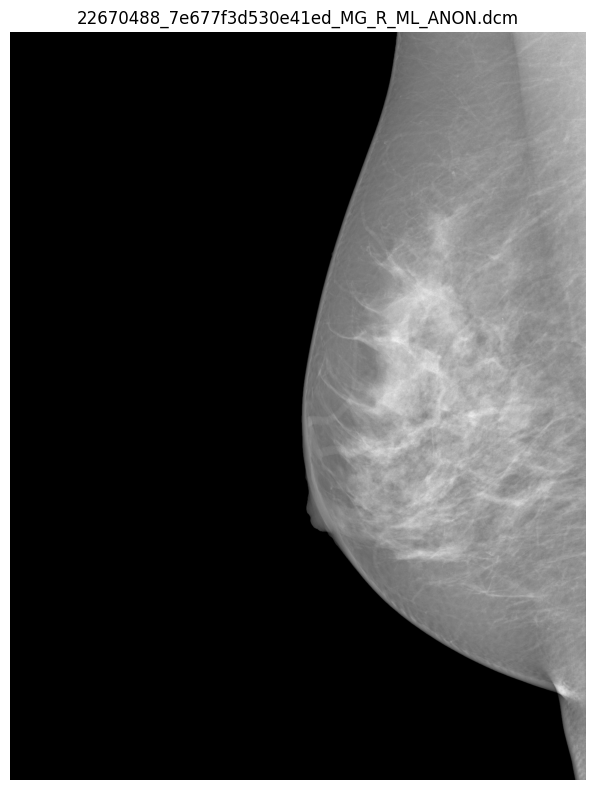

In [12]:
figure, axis, image = show_dicom_image(image_index=idx)
image.shape

## Metadatos y preprocesado
Esta seccion muestra una mamografia tras aplicar windowing y segmentacion de fondo, junto con una superposicion de la mascara sobre la imagen original.

In [25]:
import matplotlib.pyplot as plt

from src.preprocessing import (
    apply_background_mask,
    # apply_windowing,
    load_dicom_pixels,
    read_dicom_metadata,
    segment_breast_region,
 )

from src.apply_windowing import *
from src.calculate_windowing import get_dicom_voi_lut_params, calculate_windowing, should_invert_monochrome1, normalize_photometric

from src.visualization import DEFAULT_INBREAST_IMAGES_DIR, list_dicom_images

In [20]:
image_path = list_dicom_images(DEFAULT_INBREAST_IMAGES_DIR)[idx]
metadata = read_dicom_metadata(image_path)
print(metadata)

{'image_path': '/home/eloygarcia/Escritorio/Datasets/inbreast/ALL-IMGS/22670488_7e677f3d530e41ed_MG_R_ML_ANON.dcm', 'file_name': '22670488_7e677f3d530e41ed_MG_R_ML_ANON.dcm', 'PatientID': '', 'StudyDate': '', 'Modality': 'OT', 'Manufacturer': None, 'Rows': 3328, 'Columns': 2560, 'BitsStored': 16, 'PhotometricInterpretation': 'MONOCHROME2', 'PixelSpacing': None, 'ViewPosition': None, 'ImageLaterality': None, 'WindowCenter': None, 'WindowWidth': None, 'RescaleIntercept': None, 'RescaleSlope': None}


In [22]:
print(should_invert_monochrome1(metadata) )

False


In [35]:
original_image = load_dicom_pixels(image_path, normalize=False)
original_image = normalize_photometric(original_image, metadata)

# center, width = calculate_windowing(original_image) ## cambiar por 
dcm = pydicom.dcmread(image_path)
voilut = get_dicom_voi_lut_params(dcm)
print(voilut)

# windowed_image = apply_windowing(load_dicom_pixels(image_path))
windowed_image = apply_windowing(dcm,
                                 window_width = voilut['window_width'],
                                 window_center = voilut['window_center'],
                                 voi_func = voilut['voi_lut_function'],
                                 y_min = image.min(),
                                 y_max =  image.max() )
                                 
                                 
breast_mask = segment_breast_region(windowed_image)
processed_image = apply_background_mask(windowed_image, breast_mask)

{'window_center': 1497, 'window_width': 825, 'rescale_intercept': 0.0, 'rescale_slope': 1.0, 'voi_lut_function': 'LINEAR'}


AttributeError: 'FileDataset' object has no attribute 'astype'

In [14]:
figure, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(original_image, cmap='gray')
axes[0].set_title('Imagen original normalizada')
axes[0].axis('off')

axes[1].imshow(original_image, cmap='gray')
axes[1].imshow(breast_mask, cmap='autumn', alpha=0.25)
axes[1].set_title('Mascara solapada')
axes[1].axis('off')

axes[2].imshow(processed_image, cmap='gray')
axes[2].set_title('Imagen tras procesado')
axes[2].axis('off')

figure.tight_layout()

visible_metadata = {
    key: value
    for key, value in metadata.items()
    if value not in (None, '', [], {})
}

for key, value in visible_metadata.items():
    print(f'{key}: {value}')

TypeError: '>' not supported between instances of 'NoneType' and 'int'

## Etiqueta pectoral en imagenes MLO
Esta seccion carga una imagen MLO con mascara pectoral disponible y genera una mascara etiquetada con tres clases: fondo, mama y musculo pectoral.

Imagen MLO: 20586960_6c613a14b80a8591_MG_R_ML_ANON.dcm
Mascara pectoral: 20586960_mask.png
Etiquetas presentes: [0, 1, 2]


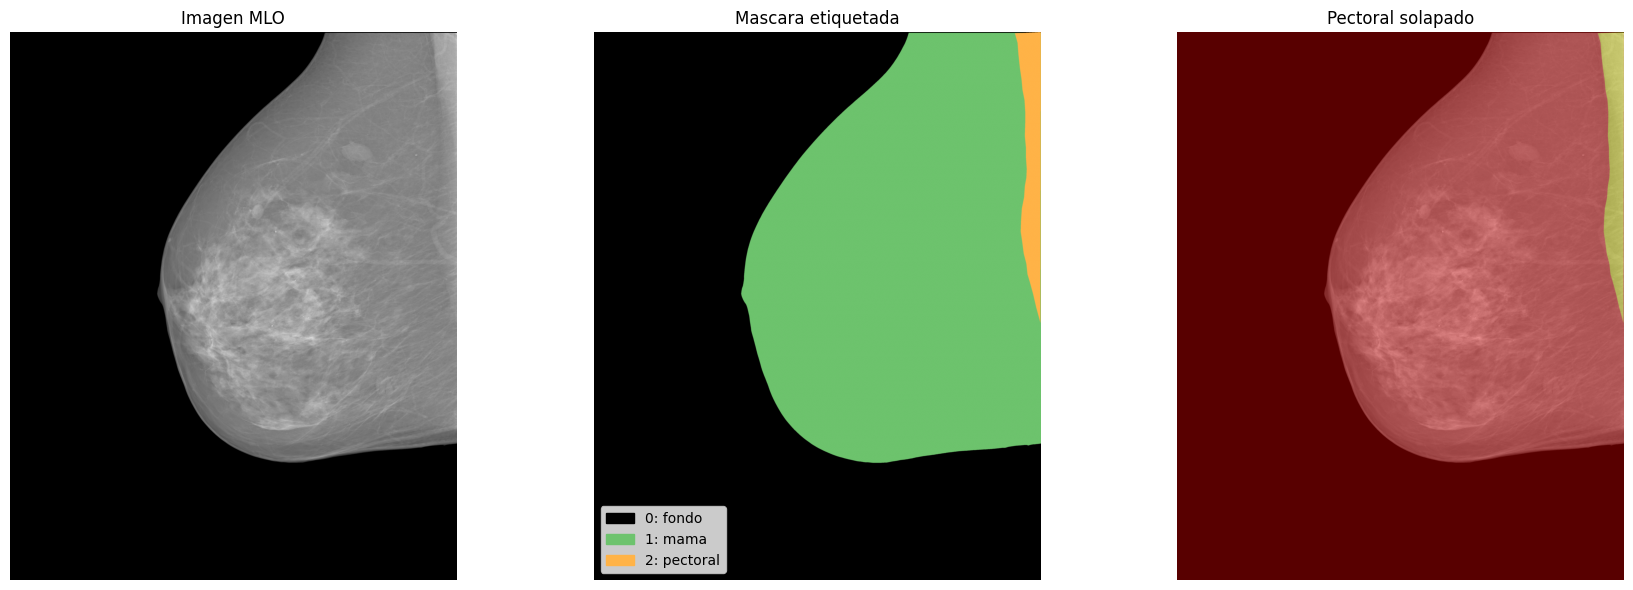

In [6]:
import importlib

from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

import src.preprocessing as preprocessing
from src.visualization import list_dicom_images

preprocessing = importlib.reload(preprocessing)

mlo_image_path = next(
    path
    for path in list_dicom_images()
    if '_ML_' in path.name and preprocessing.get_pectoral_mask_path(path)
 )

mlo_image = preprocessing.load_dicom_pixels(mlo_image_path, normalize=True)
pectoral_mask = preprocessing.load_pectoral_mask(mlo_image_path)
labeled_mask = preprocessing.create_mlo_labeled_mask(mlo_image_path)

label_cmap = ListedColormap(['black', '#6dc36d', '#ffb347'])

figure, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(mlo_image, cmap='gray')
axes[0].set_title('Imagen MLO')
axes[0].axis('off')

axes[1].imshow(labeled_mask, cmap=label_cmap, vmin=0, vmax=2)
axes[1].set_title('Mascara etiquetada')
axes[1].axis('off')

axes[2].imshow(mlo_image, cmap='gray')
axes[2].imshow(labeled_mask == 2, cmap='autumn', alpha=0.35)
axes[2].set_title('Pectoral solapado')
axes[2].axis('off')

legend_handles = [
    Patch(facecolor='black', edgecolor='black', label='0: fondo'),
    Patch(facecolor='#6dc36d', edgecolor='#6dc36d', label='1: mama'),
    Patch(facecolor='#ffb347', edgecolor='#ffb347', label='2: pectoral'),
]
axes[1].legend(handles=legend_handles, loc='lower left', frameon=True)

figure.tight_layout()

print(f'Imagen MLO: {mlo_image_path.name}')
print(f'Mascara pectoral: {preprocessing.get_pectoral_mask_path(mlo_image_path).name}')
print(f'Etiquetas presentes: {sorted(set(labeled_mask.ravel().tolist()))}')

## Dataset de metadatos y comprobacion de dimensiones
Esta seccion carga el CSV de metadatos generado para INBreast y verifica que `Rows` y `Columns` coinciden con el tamano real de los arrays DICOM.

In [7]:
import csv
from html import escape
from itertools import islice

from IPython.display import HTML, display

metadata_csv_path = Path('~/Escritorio/Datasets/InBreast/inbreast_image_metadata.csv').expanduser()

with metadata_csv_path.open(newline='', encoding='utf-8') as csv_file:
    metadata_rows = list(csv.DictReader(csv_file))

print(f'CSV de metadatos: {metadata_csv_path}')
print(f'Numero de imagenes registradas: {len(metadata_rows)}')

preview_columns = [
    'file_name',
    'laterality',
    'view_position',
    'rows',
    'columns',
    'pixel_spacing',
    'voi_lut_function',
    'window_center',
    'window_width',
    'windowing_source',
    'has_pectoral_mask',
]

preview_rows = list(islice(metadata_rows, 5))
table_header = ''.join(f'<th>{escape(column)}</th>' for column in preview_columns)
table_body = ''.join(
    '<tr>' + ''.join(f'<td>{escape(str(row.get(column, "")))}</td>' for column in preview_columns) + '</tr>'
    for row in preview_rows
)

display(HTML(
    '<table>'
    '<thead><tr>' + table_header + '</tr></thead>'
    '<tbody>' + table_body + '</tbody>'
    '</table>'
))

CSV de metadatos: /home/eloygarcia/Escritorio/Datasets/InBreast/inbreast_image_metadata.csv
Numero de imagenes registradas: 410


file_name,laterality,view_position,rows,columns,pixel_spacing,voi_lut_function,window_center,window_width,windowing_source,has_pectoral_mask
20586908_6c613a14b80a8591_MG_R_CC_ANON.dcm,R,CC,4084,3328,,,,,not_available,False
20586934_6c613a14b80a8591_MG_L_CC_ANON.dcm,L,CC,4084,3328,,,,,not_available,False
20586960_6c613a14b80a8591_MG_R_ML_ANON.dcm,R,ML,4084,3328,,,,,not_available,True
20586986_6c613a14b80a8591_MG_L_ML_ANON.dcm,L,ML,4084,3328,,,,,not_available,True
20587054_b6a4f750c6df4f90_MG_R_CC_ANON.dcm,R,CC,3328,2560,,,,,not_available,False


In [8]:
from src.preprocessing import load_dicom_pixels

dimension_mismatches = []

for row in metadata_rows:
    image_array = load_dicom_pixels(row['image_path'])
    metadata_shape = (int(row['rows']), int(row['columns']))
    array_shape = tuple(int(value) for value in image_array.shape)

    if metadata_shape != array_shape:
        dimension_mismatches.append({
            'file_name': row['file_name'],
            'metadata_shape': metadata_shape,
            'array_shape': array_shape,
        })

print(f'Imagenes comprobadas: {len(metadata_rows)}')
print(f'Desajustes encontrados: {len(dimension_mismatches)}')

if dimension_mismatches:
    mismatch_columns = ['file_name', 'metadata_shape', 'array_shape']
    mismatch_header = ''.join(f'<th>{escape(column)}</th>' for column in mismatch_columns)
    mismatch_body = ''.join(
        '<tr>' + ''.join(f'<td>{escape(str(item[column]))}</td>' for column in mismatch_columns) + '</tr>'
        for item in dimension_mismatches[:10]
    )
    display(HTML(
        '<table>'
        '<thead><tr>' + mismatch_header + '</tr></thead>'
        '<tbody>' + mismatch_body + '</tbody>'
        '</table>'
))
else:
    print('Todas las dimensiones del CSV coinciden con las dimensiones de los arrays DICOM.')

Imagenes comprobadas: 410
Desajustes encontrados: 0
Todas las dimensiones del CSV coinciden con las dimensiones de los arrays DICOM.
